# Estimate Income Model

We need a mechanism to separate low VOT from high VOT trips.  The HH travel survey includes income reported on the HH records, but the TNC data to not include income or any other socio-economic information due to privacy restrictions.  We do know the income distribution of households from the Census tracts of the pickup and drop off locations.  We assume those are related, but maybe not 1:1.  Let's have a look.

In [7]:
import numpy as np

import pandas as pd
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')

import biogeme.biogeme as bio
import biogeme.database as biodb
from biogeme import models
from biogeme.expressions import Beta, Variable

In [3]:
# read the data - use HH survey data, not TNP data
df = pd.read_csv('out/mode_choice_estimation_file.csv')
df.head()

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,mode2,o_district,d_district,o_community,d_community,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight,day_of_week,time_period,origin_id,destination_id,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,transit_avail,walk_avail,transit_or_walk_avail,income_detailed,income_broad,num_vehicles,num_people,num_workers,num_adults,num_kids,hh_weight,income_labeled,tract_2020,hh_share_inc_under_100k,hh_share_inc_over_100k
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,32.0,8.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031320101,17031081500,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,-5.018459,6.707731,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031320101,0.341000,0.659000
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,8.0,8.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031081500,17031081403,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,0.986765,4.798943,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031081500,0.321678,0.678322
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,8.0,32.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031081403,17031320101,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,-0.323012,6.244886,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031081403,0.460539,0.539461
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,32.0,32.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15

In [6]:
# add a flag for trips made by people in HHs with <$100k, $100k+ and missing annual income
# income_broad: 
# 1	Under $30,000
# 2	$30,000-$59,999
# 3	$60,000-$99,999
# 4	$100,000-$149,999
# 5	$150,000 or more
# 999	Prefer not to answer

df['inc_under_100k'] = np.where(df['income_broad']<=3, 1, 0)
df['inc_over_100k']  = np.where((df['income_broad']==4) | (df['income_broad']==5), 1, 0)
df['inc_missing']    = np.where((df['income_broad']==999), 1, 0)

# drop missing income from this estimation
df = df[df['inc_missing']==0].copy()
df['inc_over_100k'].value_counts()

inc_over_100k
0    3292
1    2235
Name: count, dtype: int64

<Axes: xlabel='hh_share_inc_over_100k', ylabel='inc_over_100k'>

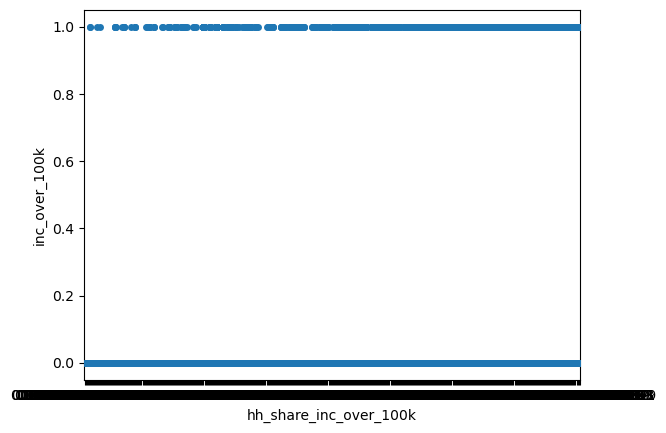

In [9]:
sns.stripplot(data=df, x='hh_share_inc_over_100k', y='inc_over_100k')

hh_id                             0
person_id                         0
person_num                        0
day_id                            0
day_num                           0
joint_trip_id                     0
joint_trip_num                 4293
depart_date                       0
depart_hour                       0
depart_minute                     0
depart_seconds                    0
arrive_date                       0
arrive_hour                       0
arrive_minute                     0
arrive_second                     0
distance_meters                   0
distance_miles                    0
duration_minutes                  0
dwell_mins                     1415
flag_speed                        0
flag_distance                     0
flag_duration                     0
o_tract_2020                      0
d_tract_2020                      0
hh_member_1                       0
hh_member_2                       0
hh_member_3                       0
hh_member_4                 

In [11]:
# prep data for a simple choice model

# drop columns with missing values that I dont' need
df = df.drop(columns=['joint_trip_num', 'dwell_mins', 'joint_tour_id', 'o_tract_2020_tour', 'd_tract_2020_tour']).copy()

# calculate normalized weights
df['normalized_weights'] = df['linked_trip_weight'] / df['linked_trip_weight'].sum() * len(df)

# Biogeme needs a NUMERIC choice column: tnc=1, transit=2, walk=3 and only numeric values in its database format. 
df_numeric = df.select_dtypes(include='number').copy()

# create the biogeme database
db = biodb.Database('income_choice', df_numeric)

In [12]:
# --- coefficients ---
# Name, starting value, lower bound, upper bound, status (0=estimate, 1=fixed)
ASC_INC_OVER_100K       = Beta('ASC_INC_OVER_100K', 0, None, None, 0)
B_TRACT_SHARE_OVER_100K = Beta('B_TRACT_SHARE_OVER_100K', 0, None, None, 0)

# --- variables ---
tract_share_over_100k     = Variable('hh_share_inc_over_100k')
CHOICE       = Variable('inc_over_100k')

# --- utility equations ---
V_low     = 0
V_high    = ASC_INC_OVER_100K + B_TRACT_SHARE_OVER_100K * tract_share_over_100k 

# specify which equations align with which alternatives, and the availability of each alternative
V  = {0: V_low, 1: V_high}
avail = {0: 1, 1: 1}          # all alternatives available for every trip

# --- estimate ---
logprob = models.loglogit(V, avail, CHOICE)
the_biogeme = bio.BIOGEME(db, logprob)
the_biogeme.modelName = 'mnl_income_choice'
the_biogeme.calculate_null_loglikelihood(avail=avail)
results = the_biogeme.estimate()

# --- print results ---
print(results.short_summary())
print(results.get_estimated_parameters())



Results for model mnl_income_choice
Nbr of parameters:		2
Sample size:			5527
Excluded data:			0
Null log likelihood:		-3831.024
Final log likelihood:		-3526.667
Likelihood ratio test (null):		608.7153
Rho square (null):			0.0794
Rho bar square (null):			0.0789
Akaike Information Criterion:	7057.334
Bayesian Information Criterion:	7070.568

                            Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_INC_OVER_100K       -2.087435      0.091133   -22.905414           0.0
B_TRACT_SHARE_OVER_100K  3.314580      0.168385    19.684572           0.0


In [14]:
# look at the observed shares

# bin hh_share_inc_over_100k into 0.1 increments
df['share_bin'] = pd.cut(df['hh_share_inc_over_100k'], bins=tract_shares, include_lowest=True)

summary = (
    df.groupby('share_bin', observed=False)
      .apply(lambda g: pd.Series({
          'count':           len(g),
          'weighted_n':      g['linked_trip_weight'].sum(),
          'weighted_share_over_100k': np.average(g['inc_over_100k'], weights=g['linked_trip_weight'])
                                      if g['linked_trip_weight'].sum() > 0 else np.nan,
      }))
)

summary


,count,weighted_n,weighted_share_over_100k
share_bin,,,
"(-0.001, 0.1]",50.0,51942.196980,0.091929
"(0.1, 0.2]",279.0,229201.933484,0.083847
"(0.2, 0.3]",606.0,439772.854499,0.205614
"(0.3, 0.4]",545.0,334225.579043,0.252527
"(0.4, 0.5]",1097.0,444179.685580,0.366301
"(0.5, 0.6]",1087.0,469708.548590,0.587372
"(0.6, 0.7]",1060.0,481983.030739,0.656031
"(0.7, 0.8]",757.0,386402.769670,0.654356
"(0.8, 0.9]",46.0,20595.946721,0.340402


In [15]:
# compare modeled vs observed weighted shares

def modeled_share(x):
    util = -2.087435 + 3.314580 * x
    return np.exp(util) / (1 + np.exp(util))

# evaluate the model at each bin midpoint and attach to the observed summary
comparison = summary.copy()
comparison['bin_midpoint']  = [interval.mid for interval in comparison.index]
comparison['modeled_share'] = comparison['bin_midpoint'].apply(modeled_share)

# reorder for easy comparison
comparison = comparison[['count', 'weighted_n', 'bin_midpoint',
                         'weighted_share_over_100k', 'modeled_share']]
comparison


,count,weighted_n,bin_midpoint,weighted_share_over_100k,modeled_share
share_bin,,,,,
"(-0.001, 0.1]",50.0,51942.196980,0.0495,0.091929,0.127487
"(0.1, 0.2]",279.0,229201.933484,0.1500,0.083847,0.169349
"(0.2, 0.3]",606.0,439772.854499,0.2500,0.205614,0.221182
"(0.3, 0.4]",545.0,334225.579043,0.3500,0.252527,0.283466
"(0.4, 0.5]",1097.0,444179.685580,0.4500,0.366301,0.355288
"(0.5, 0.6]",1087.0,469708.548590,0.5500,0.587372,0.434278
"(0.6, 0.7]",1060.0,481983.030739,0.6500,0.656031,0.516754
"(0.7, 0.8]",757.0,386402.769670,0.7500,0.654356,0.598327
"(0.8, 0.9]",46.0,20595.946721,0.8500,0.340402,0.674796


In [17]:
# goodness of fit vs observed weighted shares, weighted by bin count

def gof(observed, predicted, weights):
    obs  = np.asarray(observed,  dtype=float)
    pred = np.asarray(predicted, dtype=float)
    w    = np.asarray(weights,   dtype=float)
    mask = ~(np.isnan(obs) | np.isnan(pred))   # drop empty bins
    obs, pred, w = obs[mask], pred[mask], w[mask]

    resid   = obs - pred
    w_mean  = np.average(obs, weights=w)
    ss_res  = np.sum(w * resid**2)
    ss_tot  = np.sum(w * (obs - w_mean)**2)
    return pd.Series({
        'n_bins':   mask.sum(),
        'n_obs':    w.sum(),
        'R2':       1 - ss_res / ss_tot,
        'RMSE':     np.sqrt(np.sum(w * resid**2) / w.sum()),
        'MAE':      np.sum(w * np.abs(resid)) / w.sum(),
    })

obs = comparison['weighted_share_over_100k']
wts = comparison['count']
fit = pd.DataFrame({
    'bin_midpoint':  gof(obs, comparison['bin_midpoint'],  wts),
    'modeled_share': gof(obs, comparison['modeled_share'], wts),
})
fit


,bin_midpoint,modeled_share
n_bins,9.000000,9.000000
n_obs,5527.000000,5527.000000
R2,0.826382,0.726137
RMSE,0.080476,0.101073
MAE,0.060661,0.078859


My takeaway is that I'm actually better off assuming a really simple share according to the percentages in the Census tracts. 